# Learning-CBF — multi-run comparison

Compare runs side-by-side. Each section ends with auto-printed conclusions.

1. **Load** — scan `runs/cbfs/index.csv`, attach dataset stats, compute violations.
2. **Overview** — leaderboard + auto-conclusions (best/worst/Pareto).
3. **Pick runs** — multi-select dropdown for the rest of the notebook.
4. **Cross-run metric plots** — violations, runtime, ‖θ‖.
5. **Dataset distributions** — kNN sparsity / (x,y) density / heading coverage of the picked runs' datasets.
6. **Dataset-stat ↔ violation correlations** — what dataset features predict good CBFs.
7. **Level-set viewer** — single-select dropdown to flip h-contours of any picked run.

In [1]:
# --- setup: load every run, attach dataset stats, compute violations ---
import json, sys
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.patches import Circle
from scipy.spatial import cKDTree
import ipywidgets as W
from IPython.display import display

REPO = Path.cwd()
sys.path.append(str(REPO))
import pipeline_io as pio

METHODS = ("rff", "nn")
VIOL_W  = dict(safe=1.0, unsafe=1.0, dyn=0.5)

# ---- RFF model loader (extend as new methods arrive) ----
def _phi_rff(x, W_, b):
    L = W_.shape[0]
    return np.sqrt(2.0 / L) * np.cos(x @ W_.T + b)
def _dphi_rff(x, W_, b):
    L = W_.shape[0]
    z = x @ W_.T + b
    return -np.sqrt(2.0 / L) * np.sin(z)[:, :, None] * W_[None, :, :]
def load_model_fn(run_dir, method):
    if method == "rff":
        m = np.load(run_dir / "model.npz")
        th, Wm, b = m["theta"], m["W"], m["b"]
        return (lambda x: _phi_rff(x, Wm, b) @ th,
                lambda x: np.einsum("ilk,l->ik", _dphi_rff(x, Wm, b), th))
    raise NotImplementedError(method)

def load_dataset(ds_tag):
    d = pio.resolve_existing(pio.STAGE_DATA, ds_tag)
    safe   = pd.read_csv(d / "safe.csv").to_numpy()
    unsafe = pd.read_csv(d / "unsafe.csv").to_numpy()
    expert = pd.read_csv(d / "expert_safe.csv")
    return dict(dir=d, safe=safe, unsafe=unsafe,
                X_exp=expert[["x","y","theta"]].to_numpy(),
                U_exp=expert[["v","omega"]].to_numpy())

def compute_violations(run_dir, method, cfg, ds):
    cache = run_dir / "verification.json"
    if cache.exists():
        return json.loads(cache.read_text())
    h, grad = load_model_fn(run_dir, method)
    gs, gu, gd = cfg["gamma_safe"], cfg["gamma_unsafe"], cfg["gamma_dyn"]
    h_s, h_u, h_e = h(ds["safe"]), h(ds["unsafe"]), h(ds["X_exp"])
    v_e, om_e, th_e = ds["U_exp"][:,0], ds["U_exp"][:,1], ds["X_exp"][:,2]
    xdot = np.column_stack([v_e*np.cos(th_e), v_e*np.sin(th_e), om_e])
    q = (grad(ds["X_exp"]) * xdot).sum(axis=1) + h_e
    out = dict(safe   = 100.0*float((h_s - gs < 0).mean()),
               unsafe = 100.0*float((-h_u - gu < 0).mean()),
               dyn    = 100.0*float((q - gd < 0).mean()))
    out["total"] = VIOL_W["safe"]*out["safe"] + VIOL_W["unsafe"]*out["unsafe"] + VIOL_W["dyn"]*out["dyn"]
    cache.write_text(json.dumps(out, indent=2))
    return out

def dataset_metrics(ds, obs, theta_w=0.5, k=5, nx=40, ny=40, n_theta_bins=12, sigma_band=0.15):
    X_exp, X_safe, X_uns = ds["X_exp"], ds["safe"], ds["unsafe"]
    X = np.vstack([X_exp, X_safe, X_uns])
    lbl = np.concatenate([np.zeros(len(X_exp), int), np.ones(len(X_safe), int), np.full(len(X_uns), 2, int)])
    emb = np.column_stack([X[:,0], X[:,1], theta_w*np.cos(X[:,2]), theta_w*np.sin(X[:,2])])
    knn = cKDTree(emb).query(emb, k=k+1)[0][:, -1]
    xmin,xmax,ymin,ymax = X[:,0].min(), X[:,0].max(), X[:,1].min(), X[:,1].max()
    H_xy, xe, ye = np.histogram2d(X[:,0], X[:,1], bins=[nx,ny], range=[[xmin,xmax],[ymin,ymax]])
    p = H_xy / H_xy.sum(); pnz = p[p>0]
    tb = np.floor((X_exp[:,2] % (2*np.pi)) / (2*np.pi) * n_theta_bins).astype(int)
    xb = np.clip(np.searchsorted(xe, X_exp[:,0], side="right")-1, 0, nx-1)
    yb = np.clip(np.searchsorted(ye, X_exp[:,1], side="right")-1, 0, ny-1)
    seen = {}
    for xi, yi, ti in zip(xb, yb, tb): seen.setdefault((xi,yi), set()).add(ti)
    head_per_cell = np.array([len(s) for s in seen.values()]) if seen else np.array([0])
    cx, cy, r = obs; r_band = r + 0.1
    def _band(a, lo, hi):
        d = np.hypot(a[:,0]-cx, a[:,1]-cy); return int(((d>lo)&(d<=hi)).sum())
    near = _band(X_exp, r_band, r_band+sigma_band) + _band(X_safe, r_band, r_band+sigma_band)
    return dict(
        n_safe=len(X_safe), n_unsafe=len(X_uns), n_expert=len(X_exp),
        knn_p95=float(np.quantile(knn, 0.95)),
        knn_median=float(np.median(knn)),
        xy_occupancy=float((H_xy>0).mean()),
        xy_entropy_frac=float(-(pnz*np.log(pnz)).sum() / np.log(H_xy.size)),
        heading_mean=float(head_per_cell.mean()),
        boundary_safe_ratio=float(near / max(len(X_uns), 1)),
        _knn=knn, _lbl=lbl, _X=X, _H_xy=H_xy, _bbox=(xmin,xmax,ymin,ymax), _obs=obs,
    )

def pareto_mask(P):
    P = np.asarray(P, float); n = len(P); keep = np.ones(n, bool)
    for i in range(n):
        if not keep[i]: continue
        dom = np.all(P <= P[i], axis=1) & np.any(P < P[i], axis=1); dom[i] = False
        if dom.any(): keep[i] = False
    return keep

# ---- scan index ----
idx_p = pio.RUNS_DIR / "cbfs" / "index.csv"
idx_all = pd.read_csv(idx_p)
idx_all = idx_all[idx_all["method"].isin(METHODS)].copy()

DS_CACHE, DS_FULL_CACHE = {}, {}
def _ds_scalar(tag):
    if tag in DS_CACHE: return DS_CACHE[tag]
    d = load_dataset(tag)
    c = json.loads((d["dir"]/"config.json").read_text())
    obs = (c["obstacle"]["x"], c["obstacle"]["y"], c["obstacle"]["radius"])
    m = dataset_metrics(d, obs)
    DS_FULL_CACHE[tag] = (d, m, obs)
    DS_CACHE[tag] = {k:v for k,v in m.items() if not k.startswith("_")}
    return DS_CACHE[tag]

rows = []
for _, r in idx_all.iterrows():
    method = r["method"]
    try:
        rd  = pio.resolve_existing(pio.STAGE_CBF, r["tag"], method=method)
        cfg = json.loads((rd / "config.json").read_text())
        met = json.loads((rd / "metrics.json").read_text())
        ds  = load_dataset(r["dataset_tag"])
        v   = compute_violations(rd, method, cfg, ds)
        ds_s = _ds_scalar(r["dataset_tag"])
    except Exception as e:
        print(f"  ! skip {method}/{r['tag']}: {e}"); continue
    rows.append(dict(method=method, tag=r["tag"], dataset=r["dataset_tag"],
                     n_features=cfg.get("n_features"), sigma=cfg.get("sigma"),
                     theta_norm=met.get("theta_norm"), runtime_s=met.get("runtime_s"),
                     v_safe=v["safe"], v_unsafe=v["unsafe"], v_dyn=v["dyn"], v_total=v["total"],
                     _ts=r["_ts"], **ds_s))

runs = pd.DataFrame(rows).sort_values("v_total").reset_index(drop=True)
P3 = runs[["v_total","runtime_s","theta_norm"]].to_numpy()
runs["pareto"] = pareto_mask(np.nan_to_num(P3, nan=np.inf))
print(f"loaded {len(runs)} runs / {runs['dataset'].nunique()} datasets / methods={sorted(runs['method'].unique())}")

loaded 11 runs / 6 datasets / methods=['rff']


## 1. Overview leaderboard

Sorted by `v_total = v_safe + v_unsafe + 0.5·v_dyn`. The block at the bottom prints the best/worst on each axis so you don't need to read the table.

In [2]:
show_cols = ["pareto","method","tag","n_features","sigma",
             "v_safe","v_unsafe","v_dyn","v_total","theta_norm","runtime_s",
             "n_expert","boundary_safe_ratio","xy_entropy_frac","dataset"]
with pd.option_context("display.max_colwidth", 55, "display.width", 240):
    print(runs[show_cols].to_string(index=False))

# ---- conclusions ----
best     = runs.iloc[0]
worst    = runs.iloc[-1]
min_uns  = runs.loc[runs["v_unsafe"].idxmin()]
fastest  = runs.loc[runs["runtime_s"].idxmin()]
n_par    = int(runs["pareto"].sum())
leak     = (runs["v_unsafe"] > 2.0).sum()
print("\n=== conclusions ===")
print(f"  best  v_total : {best['tag']:40s} ({best['v_total']:.2f}, dataset={best['dataset']})")
print(f"  worst v_total : {worst['tag']:40s} ({worst['v_total']:.2f})")
print(f"  safest (unsafe%) : {min_uns['tag']:40s} ({min_uns['v_unsafe']:.2f}%)")
print(f"  fastest solver   : {fastest['tag']:40s} ({fastest['runtime_s']:.1f}s)")
print(f"  Pareto-optimal   : {n_par}/{len(runs)} on (v_total, runtime_s, theta_norm)")
print(f"  red flag (unsafe>2%) : {leak}/{len(runs)} runs leak")

 pareto method                            tag  n_features  sigma    v_safe  v_unsafe    v_dyn   v_total  theta_norm  runtime_s  n_expert  boundary_safe_ratio  xy_entropy_frac                                                       dataset
   True    rff soft_L400_sig1.5_gs1.5__082ec5         400    1.5  0.933333  0.200000 4.298643  3.282655   42.170124  29.143649      2210             0.029333         0.829244        sig0.10_marg1.5_n1500_synU3000_bboxOv_subE5000__39b45c
   True    rff soft_L400_sig1.5_gs1.5__1937de         400    1.5  0.800000  0.066667 5.717620  3.725476   37.088493  18.082377       857             0.016333         0.770247        sig0.10_marg1.5_n1500_synU3000_bboxOv_subE2000__6f59c8
  False    rff soft_L400_sig1.3_gs1.5__3277a5         400    1.3  0.975000  0.266667 4.977376  3.730354   48.087753  49.614728      2210             0.029333         0.893521 sig0.10_marg1.2_n4000_synU3000_bboxOv_subE5000_neu600__2627ee
  False    rff soft_L400_sig1.5_gs1.5__c239a0       

## 2. Pick runs to compare

Edit `PICK_TAGS` / `PICK_DATASETS` below and re-run downstream cells. `None` = defaults (all Pareto-optimal runs / all datasets seen in picked runs). Tags are matched as substrings, so `"L400_sig1.5"` selects every run whose tag contains it.

In [3]:
# --- selection (edit me, then re-run cells below) ---
# PICK_TAGS: list of tag substrings, or None for all Pareto-optimal runs.
# PICK_DATASETS: list of dataset substrings, or None for all datasets of picked runs.
PICK_TAGS = None
PICK_DATASETS = None

def _match(values, patterns):
    if not patterns: return values
    out = []
    for v in values:
        if any(p in v for p in patterns): out.append(v)
    return out

def picked_runs():
    if PICK_TAGS is None:
        sub = runs[runs["pareto"]].copy()
        if len(sub) == 0: sub = runs.head(3).copy()
    else:
        mask = runs["tag"].apply(lambda t: any(p in t for p in PICK_TAGS))
        sub = runs[mask].copy()
        if len(sub) == 0:
            print(f"  ! no runs matched {PICK_TAGS}; falling back to all runs")
            sub = runs.copy()
    return sub

def picked_datasets():
    all_ds = sorted(runs["dataset"].unique())
    if PICK_DATASETS is None:
        return sorted(picked_runs()["dataset"].unique())
    out = [d for d in all_ds if any(p in d for p in PICK_DATASETS)]
    return out or all_ds

_sub = picked_runs()
print(f"picked {len(_sub)} run(s):")
for r in _sub.itertuples():
    print(f"  {r.method}/{r.tag}  v_total={r.v_total:.2f}  dataset={r.dataset}")
print(f"picked {len(picked_datasets())} dataset(s):")
for d in picked_datasets():
    print(f"  {d}")

picked 2 run(s):
  rff/soft_L400_sig1.5_gs1.5__082ec5  v_total=3.28  dataset=sig0.10_marg1.5_n1500_synU3000_bboxOv_subE5000__39b45c
  rff/soft_L400_sig1.5_gs1.5__1937de  v_total=3.73  dataset=sig0.10_marg1.5_n1500_synU3000_bboxOv_subE2000__6f59c8
picked 2 dataset(s):
  sig0.10_marg1.5_n1500_synU3000_bboxOv_subE2000__6f59c8
  sig0.10_marg1.5_n1500_synU3000_bboxOv_subE5000__39b45c


## 3. Cross-run metric comparison

Stacked bar of `v_safe / v_unsafe / 0.5·v_dyn` per run, plus runtime / ‖θ‖. Conclusions printed below the plot.

In [ ]:
sub = picked_runs().sort_values("v_total").reset_index(drop=True)
labels = [f"{r.method}/{r.tag.split('__')[0]}" for r in sub.itertuples()]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
x = np.arange(len(sub))
axes[0].bar(x, sub["v_safe"],   label="v_safe",   color="tab:green")
axes[0].bar(x, sub["v_unsafe"], bottom=sub["v_safe"], label="v_unsafe", color="tab:red")
axes[0].bar(x, 0.5*sub["v_dyn"], bottom=sub["v_safe"]+sub["v_unsafe"],
            label="0.5·v_dyn", color="tab:blue")
axes[0].set_xticks(x); axes[0].set_xticklabels(labels, rotation=35, ha="right", fontsize=8)
axes[0].set_ylabel("violations (%)"); axes[0].set_title("stacked violations"); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3, axis="y")

axes[1].bar(x, sub["runtime_s"], color="tab:purple")
axes[1].set_xticks(x); axes[1].set_xticklabels(labels, rotation=35, ha="right", fontsize=8)
axes[1].set_ylabel("runtime (s)"); axes[1].set_title("solver runtime"); axes[1].grid(alpha=0.3, axis="y")

axes[2].bar(x, sub["theta_norm"], color="tab:orange")
axes[2].set_xticks(x); axes[2].set_xticklabels(labels, rotation=35, ha="right", fontsize=8)
axes[2].set_ylabel("‖θ‖"); axes[2].set_title("weight magnitude"); axes[2].grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

print("\n=== conclusions (picked runs) ===")
if len(sub) >= 2:
    b, w = sub.iloc[0], sub.iloc[-1]
    print(f"  spread on v_total : {b['v_total']:.2f}  →  {w['v_total']:.2f}"
          f"   (Δ={w['v_total']-b['v_total']:+.2f}, {(w['v_total']/max(b['v_total'],1e-9)):.1f}× worse)")
    dom = "unsafe" if (sub[["v_safe","v_unsafe"]].sum().idxmax()=="v_unsafe") else "safe-margin"
    print(f"  dominant failure mode in picked set: {dom}  (v_dyn always present, mostly tradeoff with v_safe)")
    print(f"  runtime range : {sub['runtime_s'].min():.1f}s – {sub['runtime_s'].max():.1f}s")
    print(f"  ‖θ‖ range     : {sub['theta_norm'].min():.1f} – {sub['theta_norm'].max():.1f}"
          f"   (large ‖θ‖ ≈ overfit; correlate with v_dyn below)")
else:
    print("  pick ≥2 runs for a meaningful comparison.")

## 4. Dataset distribution comparison

Side-by-side for every dataset used by the *picked runs* (or use the dataset multiselect above to override). One row per dataset: kNN sparsity by class, (x,y) density, heading coverage.
The conclusions block flags which dataset has the densest boundary / most uniform coverage / best heading variety — usually the strongest predictor of CBF quality.

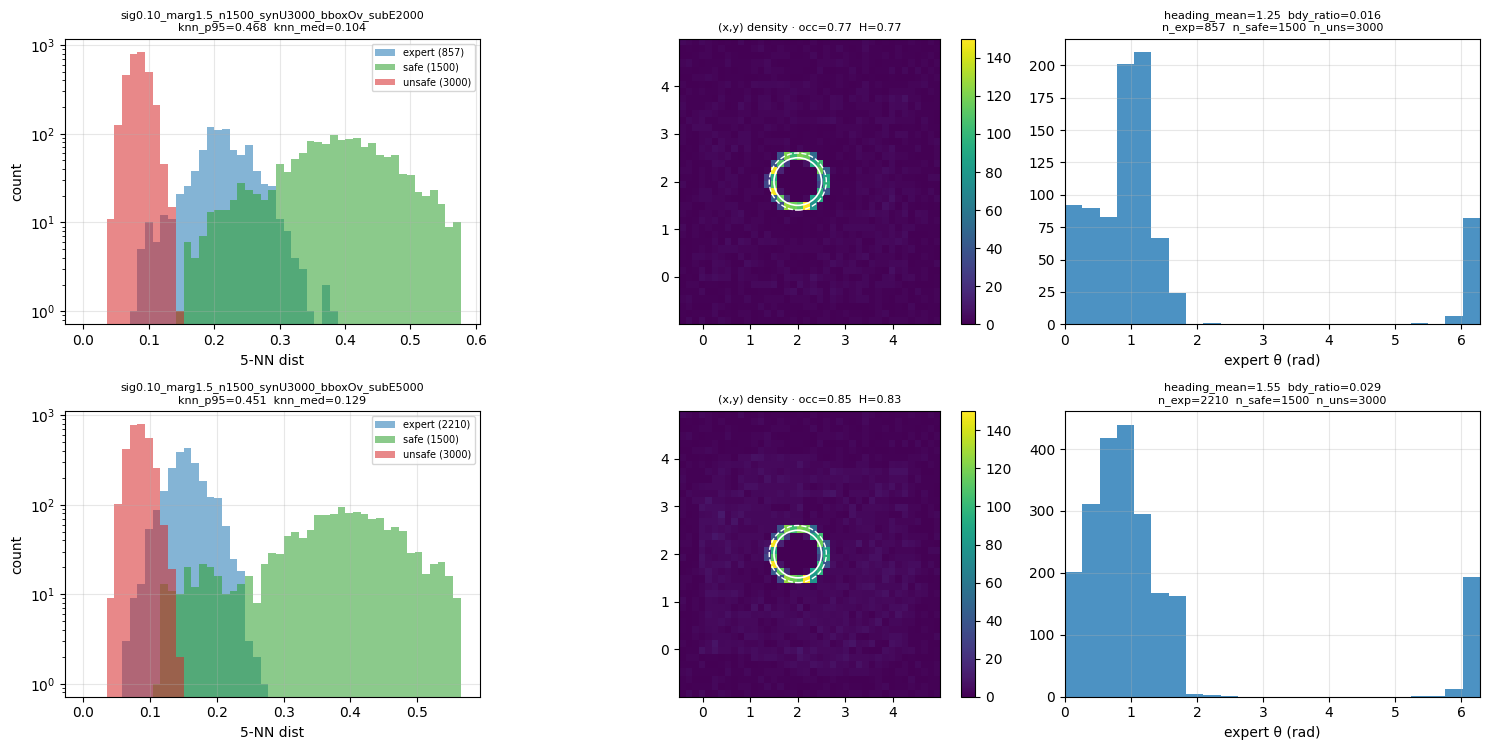


=== per-dataset summary (sorted by best v_total) ===
                                                        best_v_total  mean_v_total  n_runs  n_expert   knn_p95  xy_entropy_frac  heading_mean  boundary_safe_ratio
dataset                                                                                                                                                           
sig0.10_marg1.5_n1500_synU3000_bboxOv_subE5000__39b45c      3.282655      3.282655       1      2210  0.450865         0.829244      1.551445             0.029333
sig0.10_marg1.5_n1500_synU3000_bboxOv_subE2000__6f59c8      3.725476      3.725476       1       857  0.467762         0.770247      1.251300             0.016333

  best dataset  : sig0.10_marg1.5_n1500_synU3000_bboxOv_subE5000  → best v_total=3.28
  worst dataset : sig0.10_marg1.5_n1500_synU3000_bboxOv_subE2000  → best v_total=3.73
  axis-wise leaders:
    densest sampling (lowest knn_p95)        : sig0.10_marg1.5_n1500_synU3000_bboxOv_subE5000
    mo

In [4]:
ds_tags = picked_datasets()
# limit to datasets referenced by picked runs (intersection with multiselect)
ds_tags = [t for t in ds_tags if t in set(picked_runs()["dataset"])] or ds_tags
ds_tags = ds_tags[:6]  # cap rows

fig, axes = plt.subplots(len(ds_tags), 3, figsize=(15, 3.8*len(ds_tags)), squeeze=False)
for i, tag in enumerate(ds_tags):
    _ds_scalar(tag)  # populate DS_FULL_CACHE
    d, m, obs = DS_FULL_CACHE[tag]
    knn, lbl, X, H_xy = m["_knn"], m["_lbl"], m["_X"], m["_H_xy"]
    xmin,xmax,ymin,ymax = m["_bbox"]; cx,cy,r = obs

    ax = axes[i,0]
    bins = np.linspace(0, np.quantile(knn, 0.995), 50)
    for k_lbl, name, c in [(0,"expert","tab:blue"),(1,"safe","tab:green"),(2,"unsafe","tab:red")]:
        ax.hist(knn[lbl==k_lbl], bins=bins, alpha=0.55, color=c, label=f"{name} ({(lbl==k_lbl).sum()})")
    ax.set_yscale("log"); ax.set_xlabel("5-NN dist"); ax.set_ylabel("count")
    ax.set_title(f"{tag.split('__')[0]}\nknn_p95={m['knn_p95']:.3f}  knn_med={m['knn_median']:.3f}", fontsize=8)
    ax.legend(fontsize=7); ax.grid(alpha=0.3)

    ax = axes[i,1]
    im = ax.imshow(H_xy.T, origin="lower", extent=[xmin,xmax,ymin,ymax], cmap="viridis", aspect="equal")
    ax.add_patch(Circle((cx,cy), r, facecolor="none", edgecolor="w", lw=1.2))
    ax.add_patch(Circle((cx,cy), r+0.1, facecolor="none", edgecolor="w", lw=1, ls="--"))
    plt.colorbar(im, ax=ax, fraction=0.045)
    ax.set_title(f"(x,y) density · occ={m['xy_occupancy']:.2f}  H={m['xy_entropy_frac']:.2f}", fontsize=8)

    ax = axes[i,2]
    X_exp = d["X_exp"]
    th = (X_exp[:,2] % (2*np.pi))
    ax.hist(th, bins=24, color="tab:blue", alpha=0.8)
    ax.set_xlabel("expert θ (rad)"); ax.set_xlim(0, 2*np.pi)
    ax.set_title(f"heading_mean={m['heading_mean']:.2f}  bdy_ratio={m['boundary_safe_ratio']:.3f}\n"
                 f"n_exp={m['n_expert']}  n_safe={m['n_safe']}  n_uns={m['n_unsafe']}", fontsize=8)
    ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# conclusions: which dataset wins on each axis, and best v_total per dataset
ds_summary = (runs[runs["dataset"].isin(ds_tags)]
              .groupby("dataset")
              .agg(best_v_total=("v_total","min"),
                   mean_v_total=("v_total","mean"),
                   n_runs=("tag","count"),
                   n_expert=("n_expert","first"),
                   knn_p95=("knn_p95","first"),
                   xy_entropy_frac=("xy_entropy_frac","first"),
                   heading_mean=("heading_mean","first"),
                   boundary_safe_ratio=("boundary_safe_ratio","first"))
              .sort_values("best_v_total"))
print("\n=== per-dataset summary (sorted by best v_total) ===")
with pd.option_context("display.max_colwidth", 60, "display.width", 240):
    print(ds_summary.to_string())
if len(ds_summary) >= 2:
    winner = ds_summary.index[0]
    loser  = ds_summary.index[-1]
    print(f"\n  best dataset  : {winner.split('__')[0]}  → best v_total={ds_summary.iloc[0]['best_v_total']:.2f}")
    print(f"  worst dataset : {loser.split('__')[0]}  → best v_total={ds_summary.iloc[-1]['best_v_total']:.2f}")
    # which dataset metric correlates best with winning
    print("  axis-wise leaders:")
    print(f"    densest sampling (lowest knn_p95)        : {ds_summary['knn_p95'].idxmin().split('__')[0]}")
    print(f"    most uniform xy (highest entropy_frac)   : {ds_summary['xy_entropy_frac'].idxmax().split('__')[0]}")
    print(f"    most heading variety (heading_mean ↑)    : {ds_summary['heading_mean'].idxmax().split('__')[0]}")
    print(f"    densest boundary band                    : {ds_summary['boundary_safe_ratio'].idxmax().split('__')[0]}")

## 5. Dataset stats ↔ violations (Pearson correlation)

Across *all* runs (not just picked). Strongest absolute correlation per violation type is the dataset knob most worth tuning.

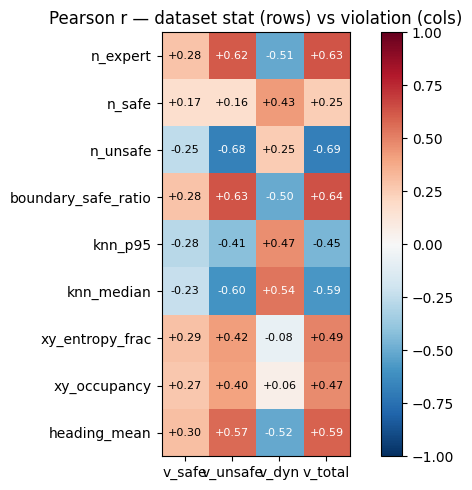


=== strongest predictors per violation ===
  v_safe   ← heading_mean            r=+0.30   (↑→↑)
  v_unsafe ← n_unsafe                r=-0.68   (↑→↓)
  v_dyn    ← knn_median              r=+0.54   (↑→↑)
  v_total  ← n_unsafe                r=-0.69   (↑→↓)

  (n=11 runs; |r| ≳ 0.67 is roughly p<0.05 — treat weaker values as noise)


In [5]:
X_FIELDS = ["n_expert","n_safe","n_unsafe","boundary_safe_ratio",
            "knn_p95","knn_median","xy_entropy_frac","xy_occupancy","heading_mean"]
Y_FIELDS = ["v_safe","v_unsafe","v_dyn","v_total"]

corr = pd.DataFrame(index=X_FIELDS, columns=Y_FIELDS, dtype=float)
for xc in X_FIELDS:
    for yc in Y_FIELDS:
        s = runs[[xc, yc]].dropna()
        corr.loc[xc, yc] = np.corrcoef(s[xc], s[yc])[0,1] if len(s) >= 3 and s[xc].std() > 0 else np.nan

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(Y_FIELDS))); ax.set_xticklabels(Y_FIELDS)
ax.set_yticks(range(len(X_FIELDS))); ax.set_yticklabels(X_FIELDS)
for i in range(len(X_FIELDS)):
    for j in range(len(Y_FIELDS)):
        v = corr.values[i,j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:+.2f}", ha="center", va="center",
                    color="white" if abs(v)>0.5 else "black", fontsize=8)
plt.colorbar(im, ax=ax, fraction=0.04)
ax.set_title("Pearson r — dataset stat (rows) vs violation (cols)")
plt.tight_layout(); plt.show()

print("\n=== strongest predictors per violation ===")
for yc in Y_FIELDS:
    col = corr[yc].dropna()
    if len(col):
        k = col.abs().idxmax()
        sign = "↑→↑" if col[k] > 0 else "↑→↓"
        print(f"  {yc:8s} ← {k:22s}  r={col[k]:+.2f}   ({sign})")
n = len(runs)
print(f"\n  (n={n} runs; |r| ≳ {2/np.sqrt(max(n-2,1)):.2f} is roughly p<0.05 — treat weaker values as noise)")

## 6. Level-set viewer

Set `VIEW_TAG`, `VIEW_THETA_DEG`, `VIEW_GRID` below (substring-match on tag; first match wins). Defaults to the best run in the picked set.

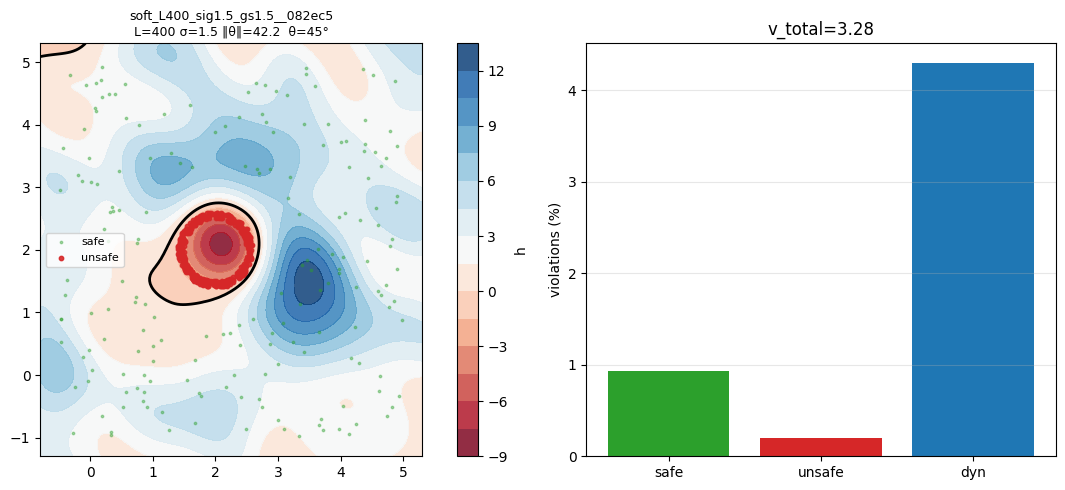

verdict: acceptable   dominant failure: dyn (4.3%)


In [6]:
# --- level-set viewer (edit + re-run) ---
VIEW_TAG       = None   # substring of run tag; None = best run in picked set
VIEW_THETA_DEG = 45
VIEW_GRID      = 140

sub_p = picked_runs().sort_values("v_total").reset_index(drop=True)
if VIEW_TAG is None:
    tag = sub_p.iloc[0]["tag"]
else:
    cands = sub_p[sub_p["tag"].str.contains(VIEW_TAG, regex=False)]
    if len(cands) == 0:
        cands = runs[runs["tag"].str.contains(VIEW_TAG, regex=False)]
    if len(cands) == 0:
        raise ValueError(f"no run tag contains {VIEW_TAG!r}")
    tag = cands.iloc[0]["tag"]

row = runs[runs["tag"] == tag].iloc[0]
rd  = pio.resolve_existing(pio.STAGE_CBF, tag, method=row["method"])
cfg = json.loads((rd/"config.json").read_text())
met = json.loads((rd/"metrics.json").read_text())
ds  = load_dataset(cfg["dataset_tag"])
h_fn, _ = load_model_fn(rd, row["method"])
viol = compute_violations(rd, row["method"], cfg, ds)

th_s = np.deg2rad(VIEW_THETA_DEG); n = VIEW_GRID
all_xy = np.vstack([ds["safe"][:,:2], ds["unsafe"][:,:2], ds["X_exp"][:,:2]])
xmin,ymin = all_xy.min(0)-0.3; xmax,ymax = all_xy.max(0)+0.3
XX, YY = np.meshgrid(np.linspace(xmin,xmax,n), np.linspace(ymin,ymax,n))
H = h_fn(np.column_stack([XX.ravel(), YY.ravel(), np.full(XX.size, th_s)])).reshape(XX.shape)

def _near(arr):
    d = np.abs(((arr[:,2]-th_s+np.pi)%(2*np.pi))-np.pi); return arr[d < np.pi/8]

fig, axes = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw=dict(width_ratios=[1.5,1]))
ax = axes[0]
cf = ax.contourf(XX, YY, H, levels=20, cmap="RdBu", alpha=0.85)
ax.contour(XX, YY, H, levels=[0.0], colors="k", linewidths=2)
plt.colorbar(cf, ax=ax, fraction=0.046, label="h")
s_, u_ = _near(ds["safe"]), _near(ds["unsafe"])
if len(s_): ax.scatter(s_[:,0], s_[:,1], s=3, c="tab:green", alpha=0.4, label="safe")
if len(u_): ax.scatter(u_[:,0], u_[:,1], s=10, c="tab:red", alpha=0.9, label="unsafe")
ax.set_aspect("equal"); ax.legend(fontsize=8)
ax.set_title(f"{tag}\nL={cfg.get('n_features')} σ={cfg.get('sigma')} "
             f"‖θ‖={met.get('theta_norm',0):.1f}  θ={VIEW_THETA_DEG}°", fontsize=9)
axes[1].bar(["safe","unsafe","dyn"], [viol["safe"], viol["unsafe"], viol["dyn"]],
            color=["tab:green","tab:red","tab:blue"])
axes[1].set_ylabel("violations (%)"); axes[1].grid(alpha=0.3, axis="y")
axes[1].set_title(f"v_total={viol['total']:.2f}")
plt.tight_layout(); plt.show()

worst = max(viol["safe"], viol["unsafe"], viol["dyn"])
mode = max((("safe",viol["safe"]),("unsafe",viol["unsafe"]),("dyn",viol["dyn"])), key=lambda kv: kv[1])[0]
verdict = ("SAFE-LEAKING" if viol["unsafe"]>2 else
           "PESSIMISTIC (tight safe set)" if viol["safe"]>5 else
           "DYN-STRUGGLING" if viol["dyn"]>10 else "acceptable")
print(f"verdict: {verdict}   dominant failure: {mode} ({worst:.1f}%)")